In [1]:
import sys
import os
import copy
import pandas as pd
import numpy as np
import json
import glob
from pathlib import Path
import albumentations as alb
from matplotlib import pyplot as plt
from dotenv import load_dotenv

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score 
from sklearn.metrics import accuracy_score, confusion_matrix

# Import this module with autoreload
%load_ext autoreload
%autoreload 2

import computervision as cv
from computervision.fileutils import FileOP
from computervision.imageproc import ImageData, is_image, plot_boxes
from computervision.datasets import DatasetFromDF
from computervision.models.lightningmodel import ToothModel
from computervision.inference import get_gpu_info

# Print version info
print(f'Package version: {cv.__version__}')
print(f'Authors:         {cv.__authors__}')
print(f'Python version:  {sys.version}')

Package version: v0.0.2
Authors:         The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.11 (main, Sep 27 2025, 18:46:04) [GCC 13.3.0]


In [2]:
# Load environmental variables
load_dotenv()
data_root = os.environ.get('DATA_DIR')
if data_root is None:
    print('Edit the "env"file and copy it to the root of the repository.') 
    raise FileNotFoundError('No .env file found. The data directory was not set.')

# Directory to store the data
dataset_name = 'computervision_data'
data_dir = os.path.join(data_root, dataset_name)
example_dir = os.path.join(data_dir, 'examples')

# URL with the data set for manual download
url = os.environ.get('CL_URL')
image_dir_name = os.path.basename(url).split('.')[0]
image_dir = os.path.join(data_dir, image_dir_name, 'cropped')

# Verify the image data on disk
file_list = glob.glob(os.path.join(image_dir, '*.jpg'))
print(len(file_list))

# Set up a model directory for the trained model
model_dir = os.path.join(data_dir, 'model', 'lightningmodel')
Path(model_dir).mkdir(exist_ok=True, parents=True)

device, device_str = get_gpu_info()

7697
CUDA available: False
Number of GPUs found:  0
Current device:    cpu


### Visualization functions ###

In [3]:
def max_f1_threshold(precision, recall, thr):
    """ Determine the threshold for the maximum f1 score """
    pdf = pd.DataFrame({'precision': np.round(precision, 4),
                        'recall': np.round(recall, 4),
                        'threshold': np.round(thr, 4)})
    pdf = pdf.assign(f1=np.round(2 * (pdf['precision'] * pdf['recall']) / (pdf['precision'] + pdf['recall']), 4))
    max_f1_dict = dict(pdf.loc[pdf['f1'] == pdf['f1'].max()].iloc[0])
    return max_f1_dict
    
def performance_plots(y_true, y_score, cl_name, figsize=(10,5)):
    # Metrics for ROC and P-R curves
    auc = roc_auc_score(y_true=y_true, y_score=y_score)
    fpr, tpr, r_thresholds = roc_curve(y_true=y_true, y_score=y_score)
    precision, recall, p_thresholds = precision_recall_curve(y_true=y_true, y_score=y_score)
    max_f1_dict = max_f1_threshold(precision=precision[:-1], recall=recall[:-1], thr=p_thresholds)
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=figsize, constrained_layout=True)
    # ROC curve
    ax[0].plot(fpr, tpr, color='k', linewidth=2.0, alpha=0.8)
    ax[0].text(x=0.75, y=0, s=f'auc={auc:.3f}', alpha=0.8)
    ax[0].set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
              xticks=np.arange(0, 1.2, 0.2), yticks=np.arange(0, 1.2, 0.2),
              xlabel='False positive rate', ylabel='True positive rate')
    ax[0].plot([0.05, 0.95], [0.05, 0.95], transform=ax[0].transAxes, color='k', 
               linewidth=2, alpha=0.8, linestyle=':')

    # PR curve
    ax[1].plot(recall, precision, color='k', linewidth=2.0, alpha=0.8)
    ax[1].text(x=0.2, y=0.43, s=f'max_f1={max_f1_dict.get("f1"):.3f}', alpha=0.8)
    ax[1].set(xlim=[-0.05, 1.05], ylim=[0.0, 1.05],
              xticks=np.arange(0, 1.2, 0.2), yticks=np.arange(0.4, 1.2, 0.2),
              xlabel='Recall (sensitivity)', ylabel='Precision')

    fig.suptitle(f'Binary detection for class "{cl_name}"', fontsize=12)
    
    return fig, ax

In [4]:
annotations_file_name = 'annotations_cropped_dset.parquet'
annotations_file = os.path.join(image_dir, annotations_file_name)
df = pd.read_parquet(annotations_file)

file_col = 'file_name'
bbox_col= 'bbox'
label_col = 'label'
dset_col = 'dset'
pred_col = 'pred'
score_col = 'score'
pos_col = 'pos'

# Check the images
file_list = [os.path.join(image_dir, file_name) for file_name in df[file_col].unique()]
checked = [is_image(file) for file in file_list]
assert len(file_list) == sum(checked), f'WARNING: Could not open all {len(file_list)} images at: {image_dir}'
print(f'Image directory:        {image_dir}')
print(f'Total number of images: {len(file_list)}')
print(f'Annotations:            {df.shape[0]}')
display(df.head(2))

Image directory:        /home/andreas/data/computervision_data/dataset_dental_roboflow/cropped
Total number of images: 7550
Annotations:            7550


,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset
0,a0ab0bec5c.jpg,tooth_02_a0ab0bec5c.jpg,152,236,35872,tooth,None,[2],None,train
1,5c6869fdf0.jpg,amalgam_03_5c6869fdf0.jpg,427,265,113155,amalgam,"[182, 29, 119, 112]","[19, 20]","[[143, 20, 284, 245], [20, 33, 382, 232]]",train


In [5]:
model_name = 'lightningmodel'
model_number = 2
model_number_str = str(model_number).zfill(2)
model_dir_name = f'{model_name}_{model_number_str}'
checkpoint_dir = os.path.join(model_dir, model_dir_name)

# Find the checkpoint files
print(checkpoint_dir)
checkpoint_files = sorted(list(glob.glob(os.path.join(checkpoint_dir, '*.ckpt'))))
checkpoint_names = [os.path.basename(file) for file in checkpoint_files]
checkpoint_dict = dict(zip(checkpoint_names, checkpoint_files))
print(f'Checkpoints found: {checkpoint_names}')

# Load model configuration
json_file = os.path.join(checkpoint_dir, f'{model_name}.json')
with open(json_file, 'r') as f:
    parameters = json.load(f)

id2label = parameters.get('id2label')
display(id2label)

# We need to add the correct categories to the test data
label2id = {label: int(id) for id, label in id2label.items()}

/home/andreas/data/computervision_data/model/lightningmodel/lightningmodel_02
Checkpoints found: ['last.ckpt', 'model-epoch=13.ckpt', 'model-epoch=23.ckpt', 'model-epoch=28.ckpt']


{'0': 'tooth',
 '1': 'amalgam',
 '2': 'caries',
 '3': 'composite',
 '4': 'Calculus',
 '5': 'root filling'}

In [6]:
# Make sure we have the correct category label for the data
df = df.assign(category=df[label_col].apply(lambda label: label2id.get(label)))
display(df.head())
label_dict = {int(category): label for category, label in id2label.items()}
display(label_dict)

,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset,category
0,a0ab0bec5c.jpg,tooth_02_a0ab0bec5c.jpg,152,236,35872,tooth,None,[2],None,train,0
1,5c6869fdf0.jpg,amalgam_03_5c6869fdf0.jpg,427,265,113155,amalgam,"[182, 29, 119, 112]","[19, 20]","[[143, 20, 284, 245], [20, 33, 382, 232]]",train,1
2,96a9546c1e.jpg,caries_08_96a9546c1e.jpg,525,253,132825,caries,"[97, 97, 46, 32]","[19, 20]","[[129, 21, 396, 232], [20, 20, 256, 233]]",train,2
3,1e36413c9e.jpg,composite_05_1e36413c9e.jpg,535,241,128935,composite,"[67, 32, 169, 87]","[29, 30]","[[213, 44, 322, 197], [20, 20, 341, 221]]",train,3
4,872cd0d6f2.jpg,tooth_15_872cd0d6f2.jpg,213,181,38553,tooth,None,[15],None,train,0


{0: 'tooth',
 1: 'amalgam',
 2: 'caries',
 3: 'composite',
 4: 'Calculus',
 5: 'root filling'}

### Test data set ###

In [7]:
# Get the test data
test_df = df.loc[df['dset'].isin(['val', 'test'])]

# Initial scaling and padding for the bigger dimension
model_info = parameters.get('model_info')
max_image_size = model_info.get('max_image_size')
print(max_image_size)

# Model input size
im_width = model_info.get('im_width')
im_height = model_info.get('im_height')
print(im_width)
print(im_height)

# Resize and then normalize 
# with ImageNet mean and standard deviation for ResNet50
image_net_mean = ImageData().image_net_mean
image_net_std = ImageData().image_net_std

# This transform is essential and needs to be applies for both training and validation
resize_and_normalize = [alb.Resize(width=im_width, height=im_height),
                        alb.Normalize(mean=image_net_mean, std=image_net_std)]

# However, for validation and testing, we don't want the augmentations, 
# so we just resize and normalize the data
test_transform = alb.Compose(resize_and_normalize)

640
224
224


In [8]:
test_df.head()

,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset,category
67,59dace8b72.jpg,amalgam_08_59dace8b72.jpg,559,280,156520,amalgam,"[124, 57, 21, 34]","[19, 20]","[[143, 32, 414, 248], [20, 20, 227, 260]]",test,1
68,8001bf10f9.jpg,caries_02_8001bf10f9.jpg,477,238,113526,caries,"[261, 111, 58, 45]","[3, 4, 5]","[[20, 0, 367, 218], [205, 1, 272, 215], [301, ...",test,2
69,f944317fd7.jpg,amalgam_07_f944317fd7.jpg,551,277,152627,amalgam,"[127, 49, 200, 85]","[20, 19, 18]","[[20, 45, 252, 232], [126, 31, 425, 246], [322...",val,1
74,cf3938122d.jpg,caries_00_cf3938122d.jpg,612,270,165240,caries,"[145, 157, 57, 32]","[2, 3]","[[20, 0, 236, 248], [185, 0, 425, 250]]",val,2
90,5c6869fdf0.jpg,amalgam_00_5c6869fdf0.jpg,438,224,98112,amalgam,"[49, 95, 160, 88]",[14],"[[20, 2, 418, 202]]",test,1


In [9]:
test_dataset = DatasetFromDF(data=test_df,
                             image_dir=image_dir,
                             file_name_col=file_col,
                             label_id_col='category',
                             max_image_size=max_image_size,
                             transform=test_transform,
                             validate=True)

print(len(test_dataset))

# Create a data loader
batch_size = 6
dl = DataLoader(test_dataset,
                batch_size=batch_size,
                num_workers=0,
                shuffle=False)

360


### Load the model from a checkpoint ###

In [10]:
print(checkpoint_names)
num_classes = len(id2label)
chk = 0 
checkpoint_name = checkpoint_names[chk]
# for chk, checkpoint_name in enumerate(checkpoint_names):
checkpoint_file = checkpoint_dict.get(checkpoint_name)
print(f'Checkpoint:      {checkpoint_name}')
print(f'Checkpoint file: {checkpoint_file}')

model = ToothModel.load_from_checkpoint(checkpoint_file,
                                        weights_only=False,
                                        test_dataset=test_dataset, 
                                        map_location=device,
                                        batch_size=batch_size,
                                        num_classes=num_classes,
                                        num_workers=1)
sm = nn.Softmax(dim=1)

['last.ckpt', 'model-epoch=13.ckpt', 'model-epoch=23.ckpt', 'model-epoch=28.ckpt']
Checkpoint:      last.ckpt
Checkpoint file: /home/andreas/data/computervision_data/model/lightningmodel/lightningmodel_02/last.ckpt


In [11]:
pred_df_batch_list = []
for image_batch, label_batch in dl:
    pred_df_batch = pd.DataFrame(sm(model(image_batch.to(device))).cpu().detach().numpy()).\
        assign(cl=list(label_batch.detach().numpy()))
    pred_df_batch_list.append(pred_df_batch)

pred_df = pd.concat(pred_df_batch_list, axis=0, ignore_index=True).\
    assign(checkpoint=checkpoint_name,
           model_name=model_name,
           model_number=model_number)

display(pred_df.head(2))

,0,1,2,3,4,5,cl,checkpoint,model_name,model_number
0,0.075461,0.003314,0.238893,0.649551,0.031932,0.000849,1,last.ckpt,lightningmodel,2
1,0.447227,0.063137,0.084307,0.200275,0.204170,0.000884,2,last.ckpt,lightningmodel,2


In [12]:
# Save the predictions
predictions_file = os.path.join(checkpoint_dir, 'test_predictions.parquet')
pred_df_save = copy.deepcopy(pred_df)
pred_df_save.columns = pred_df_save.columns.astype(str)
pred_df_save.to_parquet(predictions_file)

Performance for class 0: "tooth"
{'precision': np.float64(0.871), 'recall': np.float64(0.9), 'threshold': np.float64(0.8693000078201294), 'f1': np.float64(0.8853)}


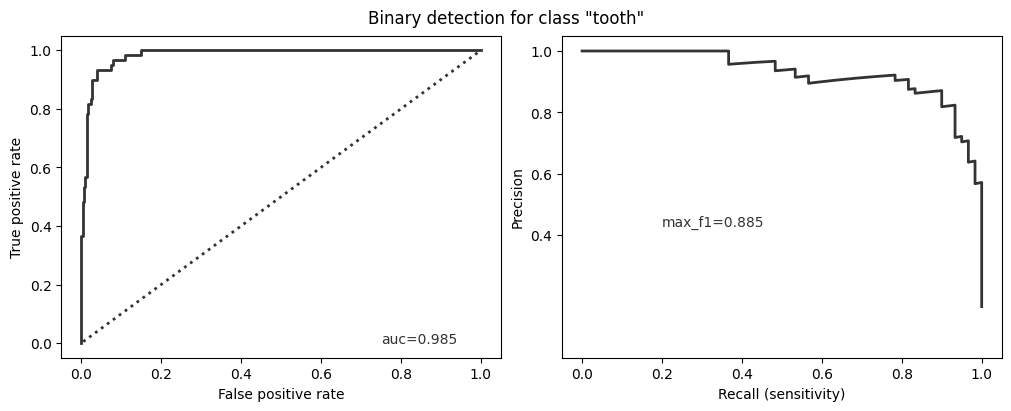


Performance for class 1: "amalgam"
{'precision': np.float64(0.4857), 'recall': np.float64(0.85), 'threshold': np.float64(0.15369999408721924), 'f1': np.float64(0.6182)}


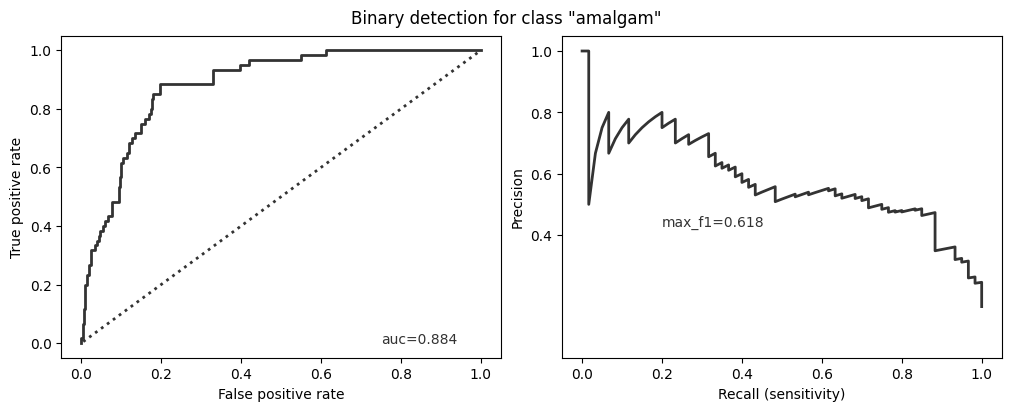


Performance for class 2: "caries"
{'precision': np.float64(0.2542), 'recall': np.float64(0.5), 'threshold': np.float64(0.1889999955892563), 'f1': np.float64(0.337)}


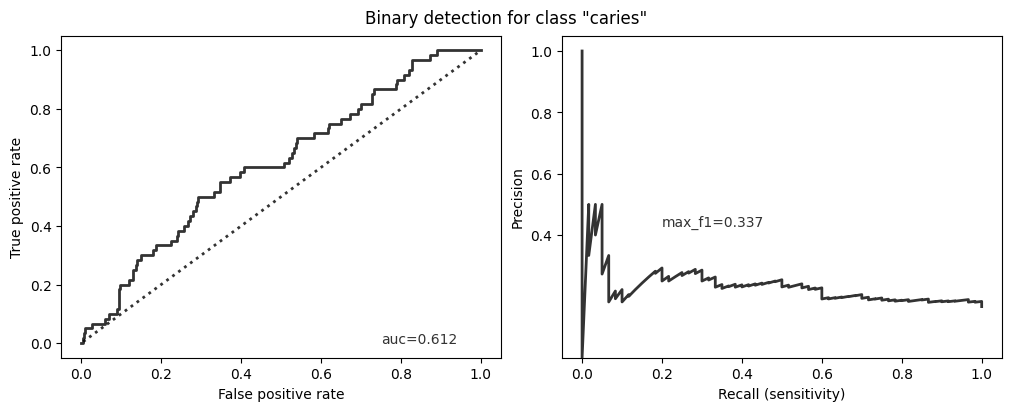


Performance for class 3: "composite"
{'precision': np.float64(0.3556), 'recall': np.float64(0.5333), 'threshold': np.float64(0.49000000953674316), 'f1': np.float64(0.4267)}


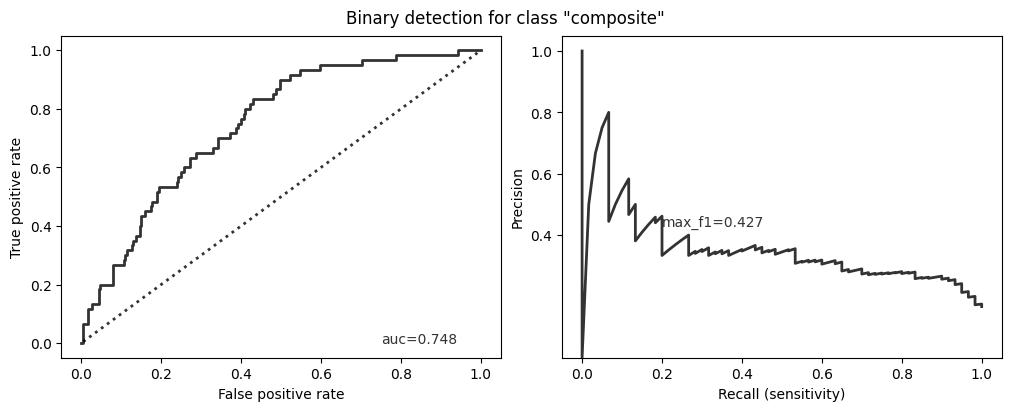


Performance for class 4: "Calculus"
{'precision': np.float64(0.4828), 'recall': np.float64(0.4667), 'threshold': np.float64(0.1876000016927719), 'f1': np.float64(0.4746)}


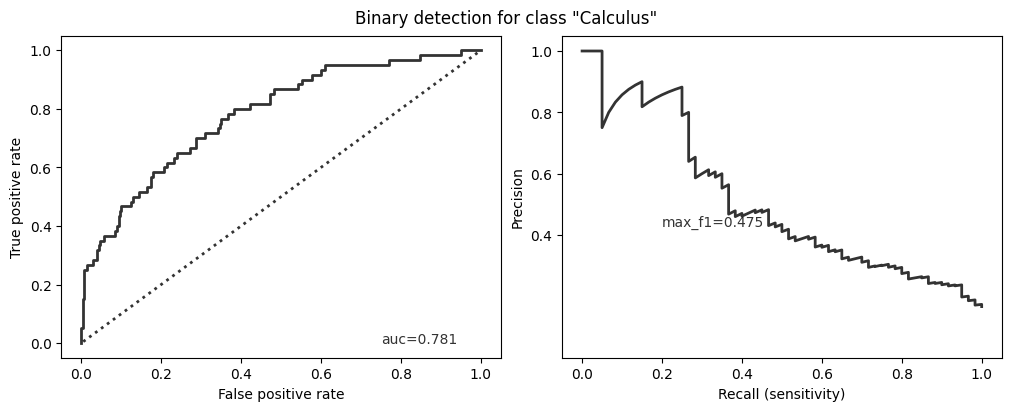


Performance for class 5: "root filling"
{'precision': np.float64(0.5889), 'recall': np.float64(0.8833), 'threshold': np.float64(0.024900000542402267), 'f1': np.float64(0.7067)}


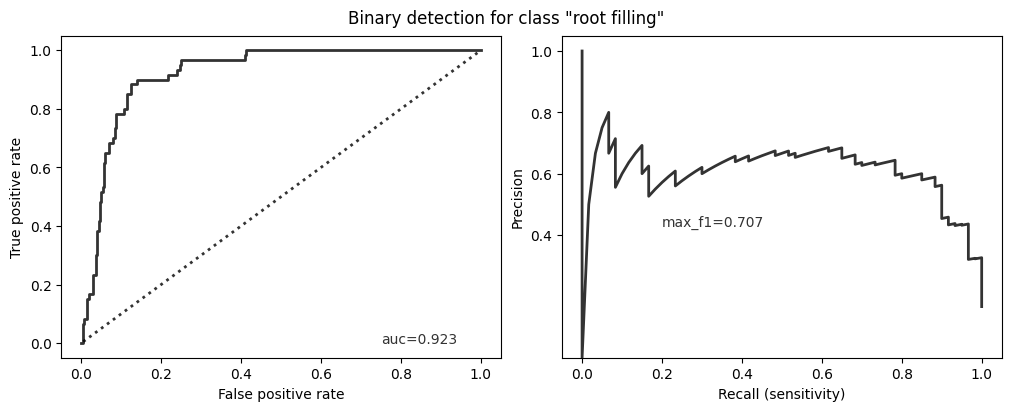

In [13]:
figsize = (10, 4)
for cl, cl_name in list(label_dict.items()):
    y_true = [1 if c == cl else 0 for c in pred_df['cl'].values]
    y_score=pred_df[cl]
    print(f'Performance for class {cl}: "{cl_name}"')
    precision, recall, p_thresholds = precision_recall_curve(y_true=y_true, y_score=y_score)
    max_f1_dict = max_f1_threshold(precision=precision[:-1], recall=recall[:-1], thr=p_thresholds)
    print(max_f1_dict)
    fig, ax = performance_plots(y_true=y_true, y_score=y_score, cl_name=cl_name, figsize=figsize)
    plt.show()
    print()

### Visualization for specific class ###

In [14]:
display(label_dict)

{0: 'tooth',
 1: 'amalgam',
 2: 'caries',
 3: 'composite',
 4: 'Calculus',
 5: 'root filling'}

rootfilling
Performance for class 5: "rootfilling"
{'precision': np.float64(0.5889), 'recall': np.float64(0.8833), 'threshold': np.float64(0.0249), 'f1': np.float64(0.7067)}


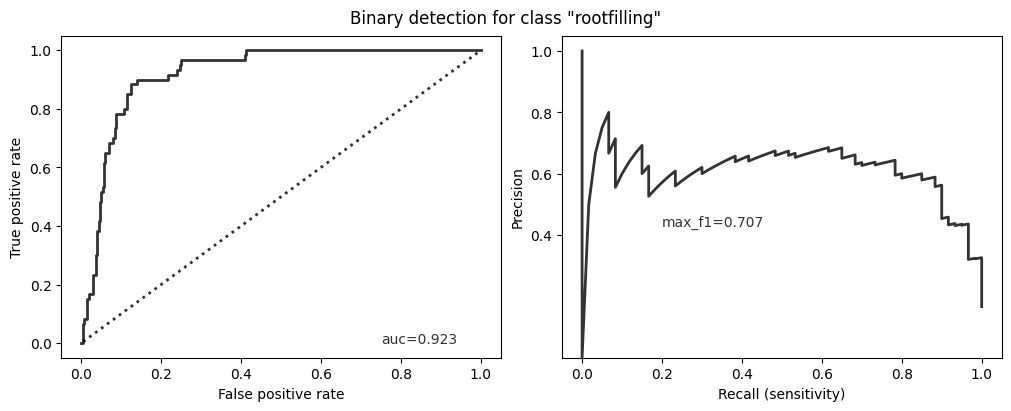

In [25]:
cl = 5
cl_name = label_dict.get(cl).replace(' ', '')
print(cl_name)
print(f'Performance for class {cl}: "{cl_name}"')

y_true = [1 if c == cl else 0 for c in pred_df['cl'].values]
y_score=pred_df[cl].tolist()

precision, recall, p_thresholds = precision_recall_curve(y_true=y_true, y_score=y_score)
max_f1_dict = max_f1_threshold(precision=precision[:-1], recall=recall[:-1], thr=p_thresholds)

print(max_f1_dict)
fig, ax = performance_plots(y_true=y_true, y_score=y_score, cl_name=cl_name, figsize=figsize)
plt.show()
print()

In [30]:
# Set the threshold to make the prediction
threshold = 0.2
y_pred = [1 if score >= threshold else 0 for score in y_score]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel().tolist()

total_positives = (tp + fn)
precision = tp/(tp + fp)
recall = tp/(tp + fn)
f1 = 2 * (precision * recall)/(precision + recall)
print(f'Class: {cl_name}')
print(f'Total positive samples in data set: {test_df.loc[test_df['category'] == cl].shape[0]} = {total_positives}')
print(f'Precision: {precision: .2f}, Recall: {recall: .2f}, F1: {f1: .2f}')

# Create a data frame
cl_dict = {file_col: test_df[file_col].tolist(),
           score_col: y_score,
           cl_name: y_true,
           pred_col: y_pred}

# Let's add the other columns
cl_df = pd.DataFrame(cl_dict)
test_cl_df = test_df.merge(cl_df, on=file_col, how='inner').\
    sort_values(by=score_col, ascending=False).\
    reset_index(drop=True)

display(test_cl_df.head())

Class: rootfilling
Total positive samples in data set: 60 = 60
Precision:  0.67, Recall:  0.58, F1:  0.63


,multi_file,file_name,width,height,area,label,bbox,pos,pos_bbox,dset,category,score,rootfilling,pred
0,59782716cb.jpg,caries_14_59782716cb.jpg,362,203,73486,caries,"[254, 44, 13, 15]","[13, 14]","[[20, 0, 342, 183], [120, 0, 242, 171]]",test,2,0.697296,0,1
1,8007815ee4.jpg,root filling_07_8007815ee4.jpg,557,241,134237,root filling,"[257, 1, 41, 60]","[13, 14]","[[20, 1, 238, 191], [150, 4, 387, 217]]",test,5,0.561100,1,1
2,757320b0da.jpg,root filling_07_757320b0da.jpg,538,238,128044,root filling,"[204, 1, 16, 46]","[13, 14]","[[20, 2, 256, 209], [140, 0, 398, 218]]",val,5,0.561015,1,1
3,a6d699ce3d.jpg,root filling_04_a6d699ce3d.jpg,251,271,68021,root filling,"[12, 108, 167, 160]",[31],"[[9, 20, 222, 251]]",test,5,0.506320,1,1
4,9bb3cd8f90.jpg,root filling_06_9bb3cd8f90.jpg,558,262,146196,root filling,"[214, 4, 51, 106]","[3, 2]","[[185, 0, 373, 231], [20, 1, 266, 241]]",val,5,0.497549,1,1


In [31]:
# Show correct predictions
test_cl_df= test_cl_df.sort_values(by=score_col, ascending=False).\
    reset_index(drop=True)

tp_file_list = test_cl_df.loc[(test_cl_df[cl_name] == 1) & (test_cl_df[pred_col] == 1), file_col].tolist()
fp_file_list = test_cl_df.loc[(test_cl_df[cl_name] == 0) & (test_cl_df[pred_col] == 1), file_col].tolist()

print(len(tp_file_list))
print(len(fp_file_list))

35
17


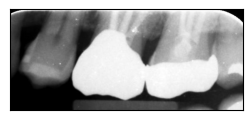

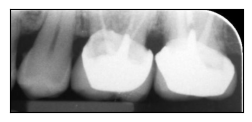

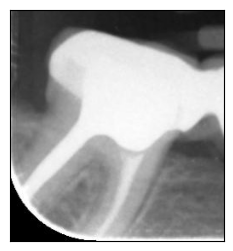

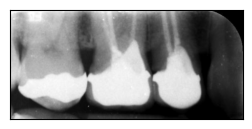

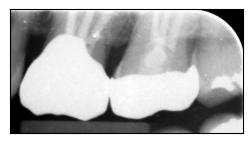

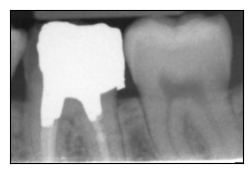

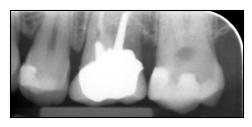

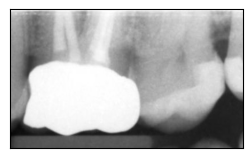

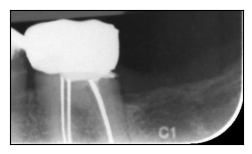

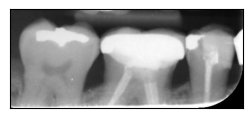

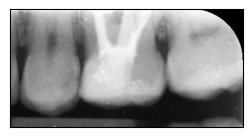

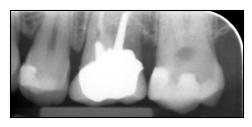

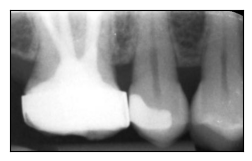

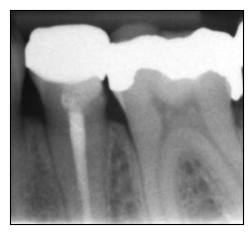

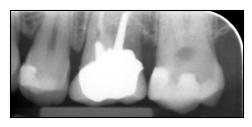

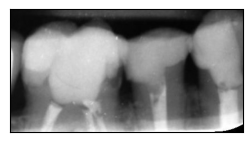

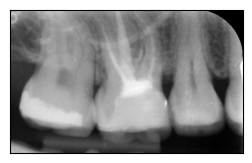

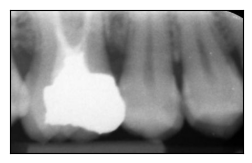

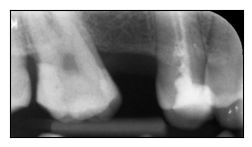

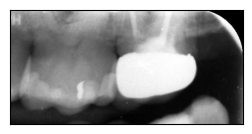

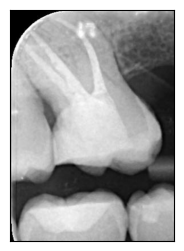

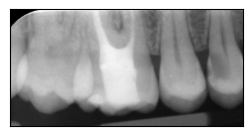

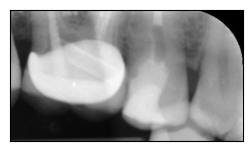

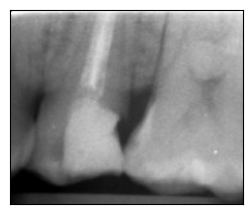

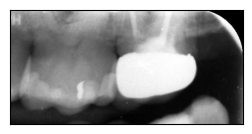

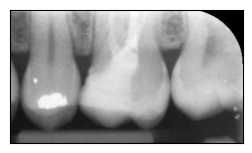

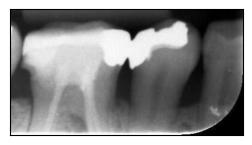

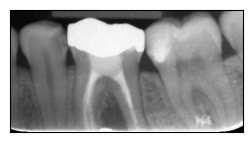

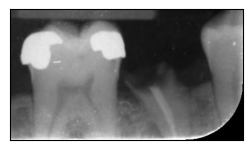

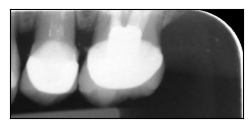

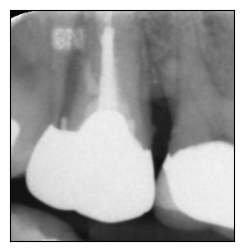

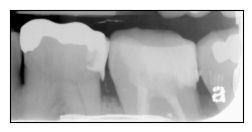

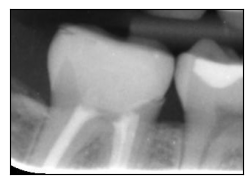

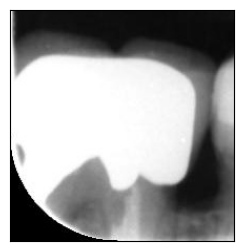

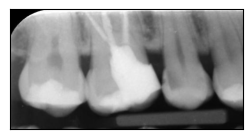

In [32]:
file_list = tp_file_list
for file_name in file_list:
    file_df = test_cl_df.loc[test_cl_df[file_col] == file_name]
    file = os.path.join(image_dir, file_name)
    box_list = list(file_df['pos_bbox'].tolist()[0][0])
    im = ImageData().load_image(file)    
    box_list = [list(file_df['pos_bbox'].tolist()[0][0])]
    fig, ax = plt.subplots(figsize = (3, 3))
    # ax = plot_boxes(image=im, box_list=box_list, ax=ax, color='r')
    ax.imshow(im)
    ax.set(xticks=[], yticks=[])
    plt.show()